# 🔴 Le Pénuromètre — Notebook Colab
### Modèle de prédiction de risque de pénurie médicamenteuse + Scraping européen

**Auteur :** BEDJIGUE Zamzam  
**Projet :** [zbaezbae.github.io/penurometre](https://zbaezbae.github.io/penurometre)  
**Stack :** Python · scikit-learn · SHAP · BeautifulSoup · Pandas  
**Théorie :** Arrow (1963) — asymétrie d'information · Akerlof (1970) — marchés des lemons

---

## Structure du notebook

| Section | Contenu |
|---------|---------|
| **1. Setup** | Installation des dépendances |
| **2. Données** | Les 45 pénuries documentées + variables explicatives |
| **3. Modèle** | Régression logistique + Random Forest |
| **4. SHAP** | Explication des prédictions variable par variable |
| **5. Visualisations** | Export PNG pour le portfolio |
| **6. Export** | `scores.json` + `coefficients.json` pour le globe |
| **7. Scraping EU** | BfArM · AFMPS · MHRA · Swissmedic |


## 1. Setup — Installation des dépendances

In [28]:
# Installation des bibliothèques nécessaires
!pip install shap scikit-learn pandas numpy matplotlib seaborn requests beautifulsoup4 -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import json
import requests
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from bs4 import BeautifulSoup

# Style matplotlib
plt.rcParams.update({
    'font.family': 'monospace',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150,
    'axes.facecolor': '#f8f9fa',
    'figure.facecolor': 'white',
})

print("✅ Dépendances chargées")


✅ Dépendances chargées


## 2. Données — Les 45 pénuries documentées

Variables explicatives utilisées dans le modèle :
- **concentration_fab** : % de production concentrée chez le principal fabricant
- **nb_fabricants** : nombre de fabricants alternatifs dans le monde
- **dependance_asie** : % de l'API produit en Chine + Inde
- **anciennete** : ancienneté du médicament en années
- **est_generique** : médicament générique (1) ou princeps (0)
- **classe_encoded** : classe thérapeutique encodée
- **cause_connue** : cause de pénurie historiquement documentée (1) ou indéterminée (0)


In [29]:
# ── Données des 45 pénuries ──────────────────────────────────────
# Variables : drug, severity, class, cause, concentration_fab,
#             nb_fabricants, dependance_asie, anciennete, est_generique

SHORTAGES_DATA = [
    # drug, severity, class, cause, conc_fab%, nb_fab, dep_asie%, anciennete_ans, est_generique
    ("Amoxicilline 500mg",            "critique",  "Antibiotiques",    "Concentration fabrication",     85, 2, 90, 60, 1),
    ("Amoxicilline/Acide clavulanique","critique",  "Antibiotiques",    "Demande excédentaire",          80, 3, 85, 45, 1),
    ("Cisplatine",                     "critique",  "Oncologie",        "Fermeture usine",               70, 2, 75, 50, 1),
    ("Carboplatine",                   "critique",  "Oncologie",        "Fermeture usine",               70, 2, 75, 35, 1),
    ("Méthotrexate injectable",        "critique",  "Oncologie",        "Problème fabrication",          65, 3, 70, 65, 1),
    ("Adderall",                       "critique",  "Neurologie",       "Demande excédentaire",          60, 4, 30, 50, 0),
    ("Morphine injectable",            "critique",  "Analgésiques",     "Arrêt fabricant",               55, 3, 40, 80, 1),
    ("Furosémide 40mg",                "critique",  "Cardiologie",      "GMP non-conformité",            50, 5, 60, 65, 1),
    ("Paracétamol IV",                 "critique",  "Analgésiques",     "Pénurie matières premières",    75, 3, 85, 55, 1),
    ("Insuline humaine NPH",           "critique",  "Diabétologie",     "Demande excédentaire",          40, 4, 50, 70, 0),
    ("Propofol",                       "critique",  "Anesthésiologie",  "Problème logistique",           45, 4, 55, 40, 1),
    ("Azithromycine 250mg",            "critique",  "Antibiotiques",    "Demande excédentaire",          70, 4, 80, 30, 1),
    ("Vincristine injectable",         "critique",  "Oncologie",        "Indéterminée",                  60, 2, 65, 60, 1),
    ("Lorazépam injectable",           "critique",  "Neurologie",       "Indéterminée",                  55, 3, 45, 55, 1),
    ("Cytarabine injectable",          "critique",  "Oncologie",        "Indéterminée",                  65, 2, 70, 55, 1),
    ("Noradrénaline injectable",       "critique",  "Cardiologie",      "Demande excédentaire",          50, 3, 55, 60, 1),
    ("Amikacine injectable",           "critique",  "Antibiotiques",    "Arrêt fabricant",               60, 3, 70, 50, 1),
    ("Ibuprofen pédiatrique",          "tension",   "Analgésiques",     "Arrêt ligne fabrication",       45, 5, 60, 50, 1),
    ("Ventoline",                      "tension",   "Pneumologie",      "Demande saisonnière",           35, 6, 30, 55, 0),
    ("Paracétamol sirop enfant",       "tension",   "Analgésiques",     "Demande saisonnière",           60, 4, 75, 55, 1),
    ("Pénicilline G injectable",       "tension",   "Antibiotiques",    "Fabricant unique",              90, 1, 60, 80, 1),
    ("Lisinopril 10mg",                "tension",   "Cardiologie",      "Augmentation demande",          40, 7, 55, 30, 1),
    ("Metformine XR",                  "tension",   "Diabétologie",     "Rappel lots contaminés",        45, 6, 60, 25, 1),
    ("Clonazépam 0.5mg",               "tension",   "Neurologie",       "Restrictions importation",      50, 4, 40, 55, 1),
    ("Doxycycline 100mg",              "tension",   "Antibiotiques",    "Concentration fournisseurs",    75, 3, 85, 60, 1),
    ("Atropine ophtalmique",           "tension",   "Ophtalmologie",    "Demande excédentaire",          55, 4, 50, 80, 0),
    ("Fentanyl transdermique",         "tension",   "Analgésiques",     "Arrêt fabricant secondaire",    50, 4, 45, 35, 0),
    ("Vancomycine IV",                 "tension",   "Antibiotiques",    "Arrêt ligne fabrication",       60, 4, 65, 45, 1),
    ("Ondansetron 4mg",                "tension",   "Gastroentérologie","Demande excédentaire",          55, 5, 60, 30, 1),
    ("Héparine sodique",               "tension",   "Cardiologie",      "Matière première",              65, 3, 70, 70, 1),
    ("Methylphenidate",                "tension",   "Neurologie",       "Hausse diagnostics",            45, 5, 35, 55, 0),
    ("Chlorhexidine solution",         "tension",   "Antiseptiques",    "Problème logistique",           40, 6, 50, 70, 1),
    ("Morphine sulfate oral",          "tension",   "Analgésiques",     "Indéterminée",                  50, 4, 40, 80, 1),
    ("Pipéracilline-Tazobactam",       "tension",   "Antibiotiques",    "Concentration fabrication",     70, 3, 75, 30, 1),
    ("Midazolam injectable",           "tension",   "Anesthésiologie",  "Arrêt fabricant",               55, 3, 50, 40, 1),
    ("Bicarbonate de sodium IV",       "tension",   "Cardiologie",      "Concentration fabrication",     60, 3, 55, 80, 1),
    ("Lévothyroxine 100µg",            "vigilance", "Endocrinologie",   "Problème qualité lot",          35, 6, 40, 60, 0),
    ("Acide folique 5mg",              "vigilance", "Hématologie",      "Augmentation demande",          30, 7, 45, 70, 1),
    ("Atorvastatine 40mg",             "vigilance", "Cardiologie",      "Tension fournisseur",           35, 8, 50, 25, 1),
    ("Prednisolone 5mg",               "vigilance", "Immunologie",      "Concentration API Chine",       65, 4, 80, 70, 1),
    ("Hydroxychloroquine",             "vigilance", "Immunologie",      "Spéculation post-COVID",        45, 5, 55, 60, 0),
    ("Tacrolimus 1mg",                 "vigilance", "Immunologie",      "Arrêt fabricant",               50, 4, 55, 30, 0),
    ("Rifampicine",                    "vigilance", "Infectiologie",    "Rupture importation",           55, 4, 65, 65, 1),
    ("Gentamicine ophtalmique",        "vigilance", "Ophtalmologie",    "Problème douanier",             45, 5, 55, 70, 1),
    ("Hydroxyzine 25mg",               "vigilance", "Neurologie",       "Indéterminée",                  40, 5, 45, 60, 1),
]

cols = ["drug", "severity", "class", "cause", "concentration_fab",
        "nb_fabricants", "dependance_asie", "anciennete", "est_generique"]

df = pd.DataFrame(SHORTAGES_DATA, columns=cols)

# Variable cible binaire : critique = 1, tension/vigilance = 0
df["target"] = (df["severity"] == "critique").astype(int)

# Encodage de la classe thérapeutique
le_class = LabelEncoder()
df["classe_encoded"] = le_class.fit_transform(df["class"])

# Variable cause connue
df["cause_connue"] = (df["cause"] != "Indéterminée").astype(int)

print(f"✅ Dataset : {len(df)} pénuries")
print(f"   Critiques : {df['target'].sum()} ({df['target'].mean():.0%})")
print(f"   Tensions  : {(df['severity']=='tension').sum()}")
print(f"   Vigilances: {(df['severity']=='vigilance').sum()}")
print()
print(df[["drug","severity","concentration_fab","nb_fabricants","dependance_asie"]].to_string(index=False))


✅ Dataset : 45 pénuries
   Critiques : 17 (38%)
   Tensions  : 19
   Vigilances: 9

                           drug  severity  concentration_fab  nb_fabricants  dependance_asie
             Amoxicilline 500mg  critique                 85              2               90
Amoxicilline/Acide clavulanique  critique                 80              3               85
                     Cisplatine  critique                 70              2               75
                   Carboplatine  critique                 70              2               75
        Méthotrexate injectable  critique                 65              3               70
                       Adderall  critique                 60              4               30
            Morphine injectable  critique                 55              3               40
                Furosémide 40mg  critique                 50              5               60
                 Paracétamol IV  critique                 75              3    

## 3. Modèle — Régression logistique + Random Forest

**Justification théorique (Arrow 1963 / Akerlof 1970) :**
- La concentration des fabricants et la dépendance asiatique représentent l'**asymétrie d'information** : les acheteurs (hôpitaux) ignorent la fragilité réelle des chaînes d'approvisionnement
- La variable `nb_fabricants = 1` (fabricant unique) illustre le mécanisme des **marchés des lemons** : l'absence de concurrence élimine les incitations à la transparence


In [30]:
# ── Variables features ───────────────────────────────────────────
FEATURES = ["concentration_fab", "nb_fabricants", "dependance_asie",
            "anciennete", "est_generique", "classe_encoded", "cause_connue"]

X = df[FEATURES].values
y = df["target"].values

# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── Régression logistique ─────────────────────────────────────────
lr = LogisticRegression(random_state=42, max_iter=1000, C=0.5)
lr.fit(X_scaled, y)

cv_lr = cross_val_score(lr, X_scaled, y, cv=StratifiedKFold(5), scoring='roc_auc')
print(f"Régression logistique — AUC CV: {cv_lr.mean():.3f} ± {cv_lr.std():.3f}")

# ── Random Forest ─────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=4)
rf.fit(X, y)

cv_rf = cross_val_score(rf, X, y, cv=StratifiedKFold(5), scoring='roc_auc')
print(f"Random Forest       — AUC CV: {cv_rf.mean():.3f} ± {cv_rf.std():.3f}")

# ── Scores de risque pour les 45 pénuries ─────────────────────────
df["risk_score_lr"] = lr.predict_proba(X_scaled)[:, 1]
df["risk_score_rf"] = rf.predict_proba(X)[:, 1]
df["risk_score"]    = (df["risk_score_lr"] + df["risk_score_rf"]) / 2  # Ensemble

# Niveau de risque prédit
def risk_level(score):
    if score >= 0.65: return "critique"
    if score >= 0.35: return "tension"
    return "vigilance"

df["predicted_severity"] = df["risk_score"].apply(risk_level)

print()
print("Top 10 molécules à plus haut risque prédit :")
top10 = df.nlargest(10, "risk_score")[["drug","severity","predicted_severity","risk_score"]]
print(top10.to_string(index=False))


Régression logistique — AUC CV: 0.567 ± 0.207
Random Forest       — AUC CV: 0.561 ± 0.233

Top 10 molécules à plus haut risque prédit :
                           drug severity predicted_severity  risk_score
          Cytarabine injectable critique           critique    0.882623
         Vincristine injectable critique           critique    0.839847
                     Cisplatine critique           critique    0.829612
                   Carboplatine critique           critique    0.800435
             Amoxicilline 500mg critique           critique    0.742904
           Lorazépam injectable critique            tension    0.645554
        Méthotrexate injectable critique            tension    0.630296
Amoxicilline/Acide clavulanique critique            tension    0.614097
                 Paracétamol IV critique            tension    0.587125
       Pénicilline G injectable  tension            tension    0.541867


## 4. SHAP — Explication des prédictions

SHAP (SHapley Additive exPlanations) quantifie la contribution de chaque variable à la prédiction, variable par variable, pour chaque molécule.


In [31]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)

# Pour la classe "critique" (index 1)
# shap_values can be a list of arrays (class 0, class 1) or a 3D array (samples, features, classes)
if isinstance(shap_values, list):
    sv = shap_values[1] # Selects the array for class 1
else:
    # If it's a 3D array (samples, features, classes), select the slice for class 1
    sv = shap_values[:, :, 1]

feature_names_fr = [
    "Concentration\nfabricant (%)",
    "Nb fabricants\nalternatifs",
    "Dépendance\nasie (%)",
    "Ancienneté\n(années)",
    "Générique\n(0/1)",
    "Classe\nthérapeutique",
    "Cause\nconnue"
]

print("✅ SHAP calculé")
print(f"   Shape SHAP values: {sv.shape}")
mean_abs_shap = np.abs(sv).mean(axis=0)
for i, (f, v) in enumerate(zip(feature_names_fr, mean_abs_shap)):
    print(f"   {f.replace(chr(10),' '):35s} : {v:.4f}")

✅ SHAP calculé
   Shape SHAP values: (45, 7)
   Concentration fabricant (%)         : 0.0385
   Nb fabricants alternatifs           : 0.0966
   Dépendance asie (%)                 : 0.0444
   Ancienneté (années)                 : 0.0352
   Générique (0/1)                     : 0.0050
   Classe thérapeutique                : 0.0364
   Cause connue                        : 0.0107


## 5. Visualisations — Export PNG

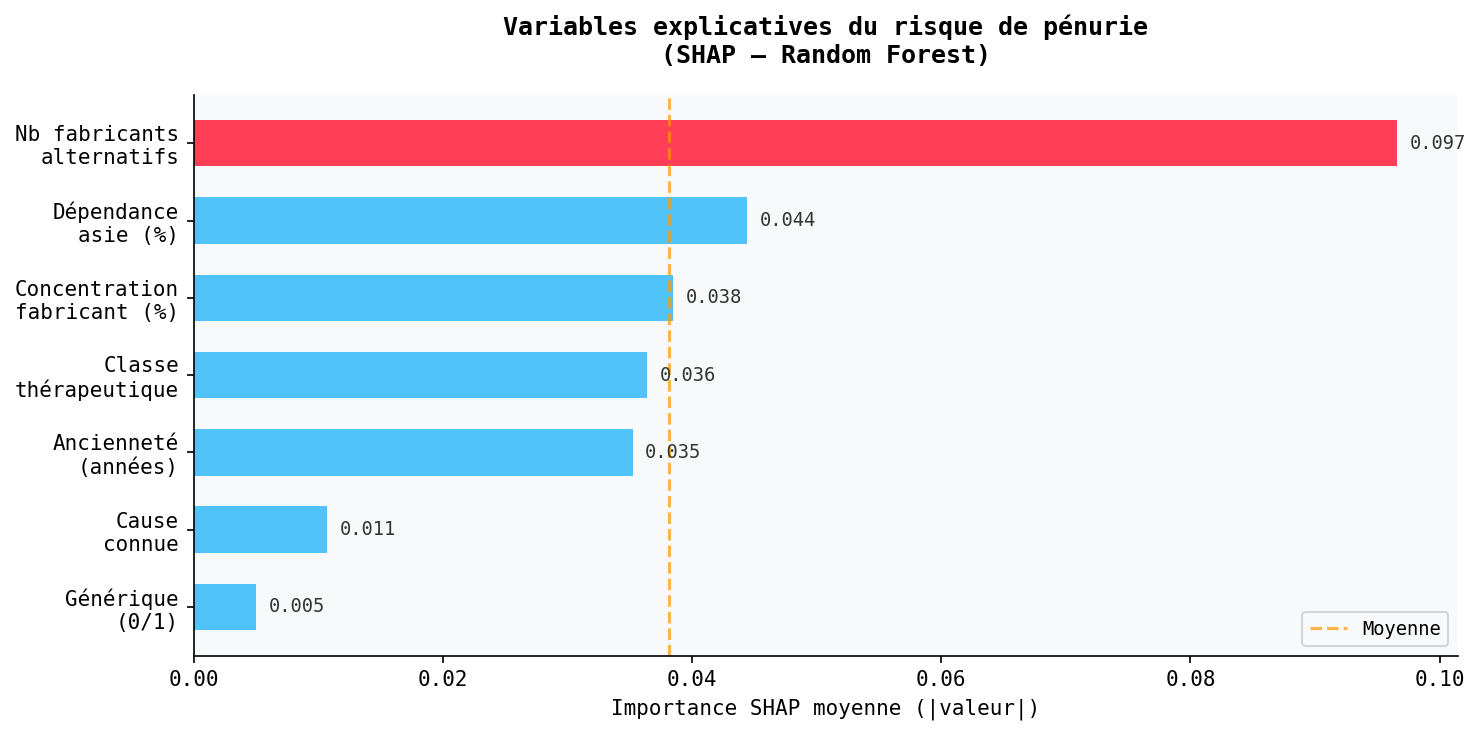

✅ shap_importance.png sauvegardé


In [32]:
import os
os.makedirs("exports", exist_ok=True)

# ── VIZ 1 : SHAP Summary Bar ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#ff3d57' if v == max(mean_abs_shap) else '#4fc3f7'
          for v in mean_abs_shap]
sorted_idx = np.argsort(mean_abs_shap)
sorted_features = [feature_names_fr[i] for i in sorted_idx]
sorted_values   = mean_abs_shap[sorted_idx]
sorted_colors   = [colors[i] for i in sorted_idx]

bars = ax.barh(sorted_features, sorted_values, color=sorted_colors, height=0.6)
ax.set_xlabel("Importance SHAP moyenne (|valeur|)", fontsize=10)
ax.set_title("Variables explicatives du risque de pénurie\n(SHAP — Random Forest)",
             fontsize=12, fontweight='bold', pad=15)

for bar, val in zip(bars, sorted_values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9, color='#333')

ax.axvline(x=np.mean(mean_abs_shap), color='#ff9800',
           linestyle='--', alpha=0.7, label='Moyenne')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("exports/shap_importance.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ shap_importance.png sauvegardé")


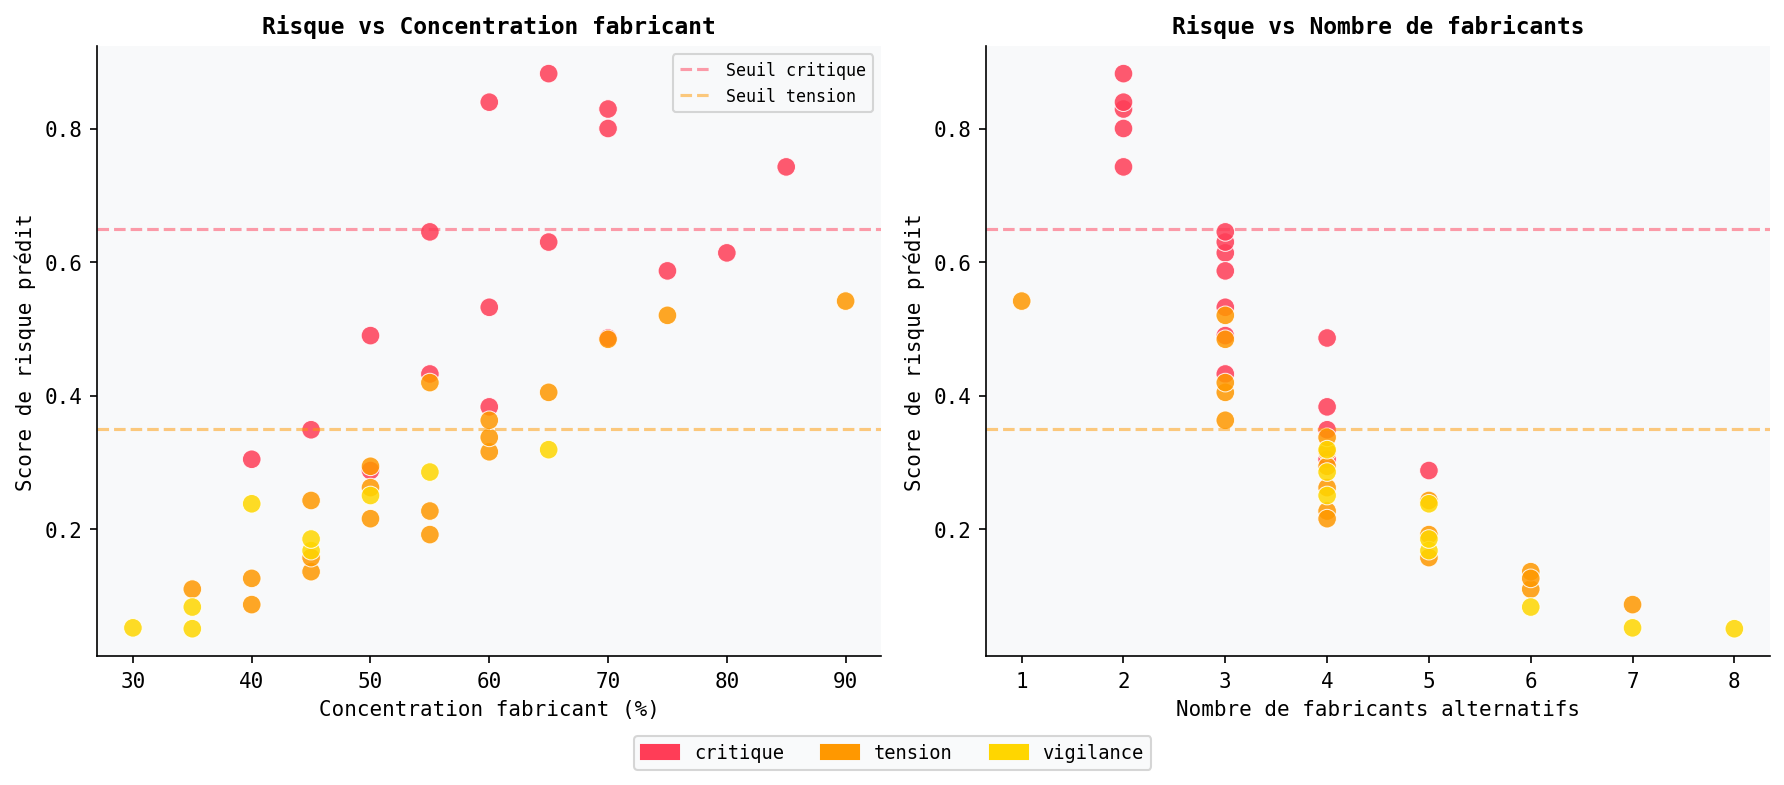

✅ scatter_risk.png sauvegardé


In [33]:
# ── VIZ 2 : Scatter — Score de risque vs Variables clés ─────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sev_colors = {'critique': '#ff3d57', 'tension': '#ff9800', 'vigilance': '#ffd600'}
colors_pts  = df['severity'].map(sev_colors)

ax1 = axes[0]
scatter = ax1.scatter(df['concentration_fab'], df['risk_score'],
                      c=colors_pts, s=80, alpha=0.85, edgecolors='white', linewidth=0.5)
ax1.set_xlabel("Concentration fabricant (%)", fontsize=10)
ax1.set_ylabel("Score de risque prédit", fontsize=10)
ax1.set_title("Risque vs Concentration fabricant", fontsize=11, fontweight='bold')
ax1.axhline(y=0.65, color='#ff3d57', linestyle='--', alpha=0.5, label='Seuil critique')
ax1.axhline(y=0.35, color='#ff9800', linestyle='--', alpha=0.5, label='Seuil tension')
ax1.legend(fontsize=8)

ax2 = axes[1]
ax2.scatter(df['nb_fabricants'], df['risk_score'],
            c=colors_pts, s=80, alpha=0.85, edgecolors='white', linewidth=0.5)
ax2.set_xlabel("Nombre de fabricants alternatifs", fontsize=10)
ax2.set_ylabel("Score de risque prédit", fontsize=10)
ax2.set_title("Risque vs Nombre de fabricants", fontsize=11, fontweight='bold')
ax2.axhline(y=0.65, color='#ff3d57', linestyle='--', alpha=0.5)
ax2.axhline(y=0.35, color='#ff9800', linestyle='--', alpha=0.5)

# Légende commune
patches = [mpatches.Patch(color=c, label=l)
           for l, c in sev_colors.items()]
fig.legend(handles=patches, loc='lower center', ncol=3,
           fontsize=9, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig("exports/scatter_risk.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ scatter_risk.png sauvegardé")


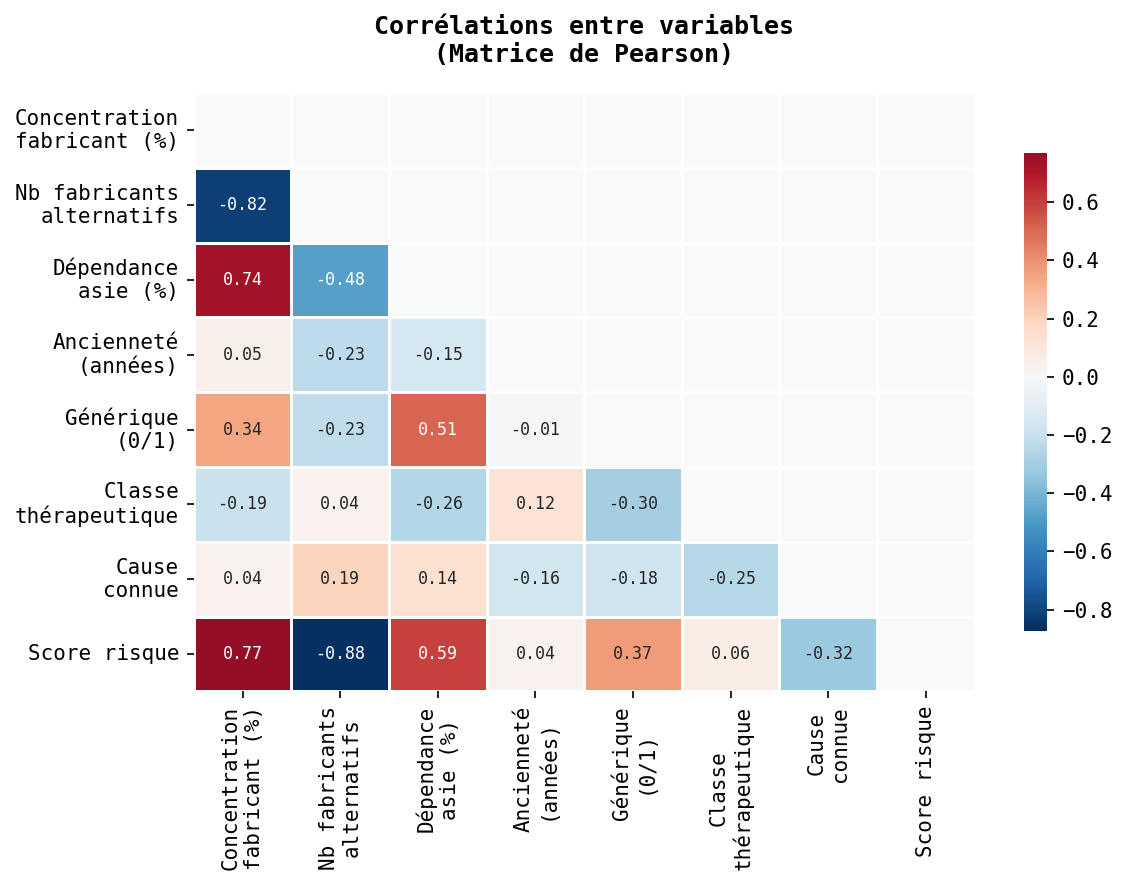

✅ correlation_heatmap.png sauvegardé


In [34]:
# ── VIZ 3 : Heatmap des corrélations ────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

corr_data = df[FEATURES + ["risk_score"]].copy()
corr_data.columns = feature_names_fr + ["Score risque"]
corr_matrix = corr_data.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap='RdBu_r', center=0, ax=ax,
            annot_kws={"size": 8}, linewidths=0.5,
            cbar_kws={"shrink": 0.8})

ax.set_title("Corrélations entre variables\n(Matrice de Pearson)",
             fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("exports/correlation_heatmap.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ correlation_heatmap.png sauvegardé")


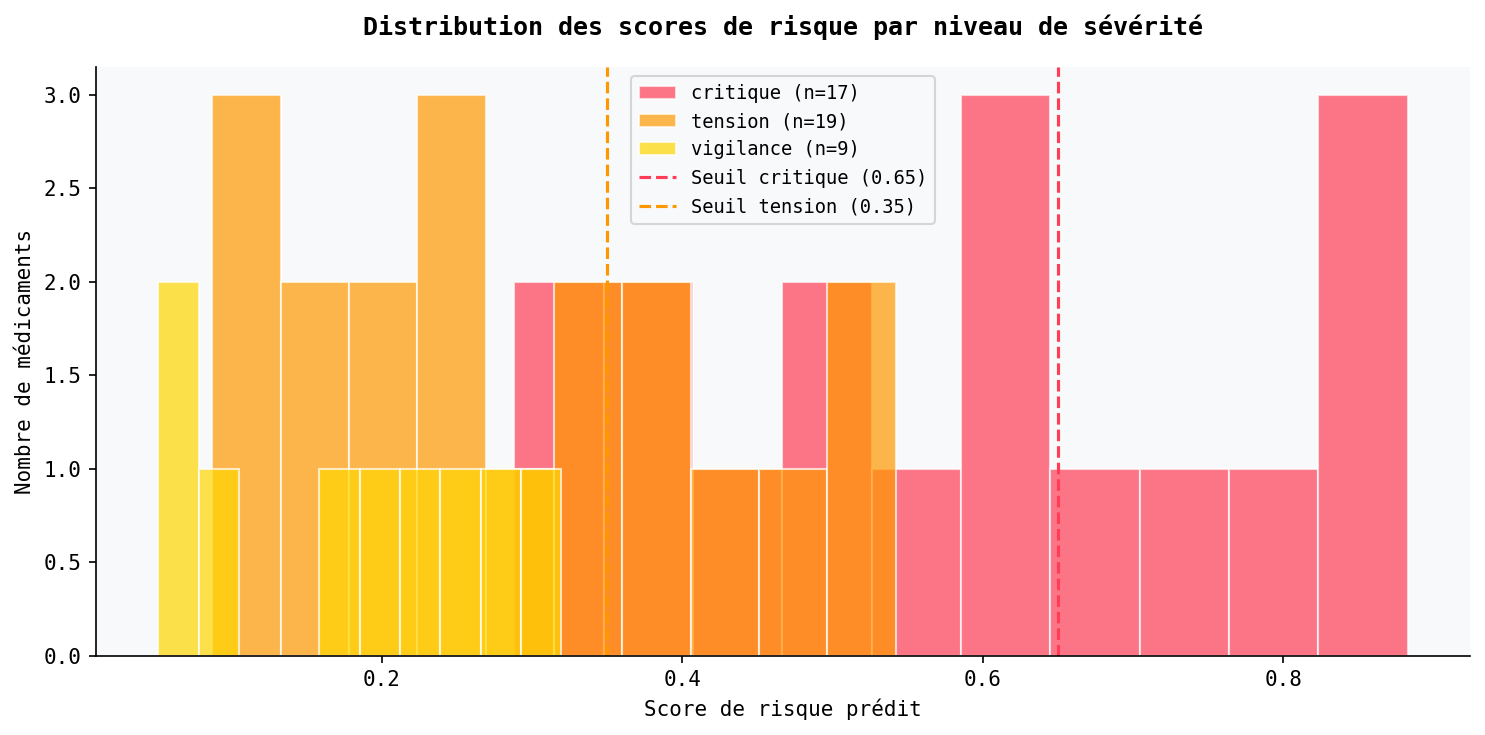

✅ risk_distribution.png sauvegardé


In [35]:
# ── VIZ 4 : Distribution des scores par sévérité ────────────────
fig, ax = plt.subplots(figsize=(10, 5))

for sev, color in sev_colors.items():
    subset = df[df['severity'] == sev]['risk_score']
    ax.hist(subset, bins=10, alpha=0.7, color=color,
            label=f'{sev} (n={len(subset)})', edgecolor='white')

ax.axvline(x=0.65, color='#ff3d57', linestyle='--',
           linewidth=1.5, label='Seuil critique (0.65)')
ax.axvline(x=0.35, color='#ff9800', linestyle='--',
           linewidth=1.5, label='Seuil tension (0.35)')
ax.set_xlabel("Score de risque prédit", fontsize=10)
ax.set_ylabel("Nombre de médicaments", fontsize=10)
ax.set_title("Distribution des scores de risque par niveau de sévérité",
             fontsize=12, fontweight='bold', pad=15)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("exports/risk_distribution.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ risk_distribution.png sauvegardé")


## 6. Export JSON pour le globe

Ces fichiers JSON sont à uploader dans le repo GitHub :
- `scores.json` → utilisé par `modele.html` et `index.html` (colorisation des points)
- `coefficients.json` → utilisé par les curseurs interactifs du simulateur


In [ ]:
# ── Export scores.json ───────────────────────────────────────────
scores_export = []
for _, row in df.iterrows():
    scores_export.append({
        "drug":               row["drug"],
        "severity":           row["severity"],
        "predicted_severity": row["predicted_severity"],
        "risk_score":         round(float(row["risk_score"]), 4),
        "risk_score_lr":      round(float(row["risk_score_lr"]), 4),
        "risk_score_rf":      round(float(row["risk_score_rf"]), 4),
        "class":              row["class"],
        "concentration_fab":  int(row["concentration_fab"]),
        "nb_fabricants":      int(row["nb_fabricants"]),
        "dependance_asie":    int(row["dependance_asie"]),
    })

with open("exports/scores.json", "w", encoding="utf-8") as f:
    json.dump(scores_export, f, ensure_ascii=False, indent=2)

print(f"✅ scores.json exporté ({len(scores_export)} entrées)")

# ── Export coefficients.json ──────────────────────────────────────
coef_dict = {
    "model": "logistic_regression + random_forest (ensemble)",
    "features": FEATURES,
    "feature_names_fr": feature_names_fr,
    "lr_coefficients": dict(zip(FEATURES, lr.coef_[0].tolist())),
    "lr_intercept": float(lr.intercept_[0]),
    "rf_feature_importances": dict(zip(FEATURES, rf.feature_importances_.tolist())),
    "shap_mean_abs": dict(zip(FEATURES, mean_abs_shap.tolist())),
    "scaler_mean": scaler.mean_.tolist(),
    "scaler_scale": scaler.scale_.tolist(),
    "thresholds": {"critique": 0.65, "tension": 0.35},
    "cv_auc_lr": round(float(cv_lr.mean()), 4),
    "cv_auc_rf": round(float(cv_rf.mean()), 4),
    "n_samples": len(df),
    "n_critique": int(df["target"].sum()),
}

with open("exports/coefficients.json", "w", encoding="utf-8") as f:
    json.dump(coef_dict, f, ensure_ascii=False, indent=2)

print("✅ coefficients.json exporté")
print()
print("📦 Fichiers à uploader dans le repo GitHub :")
print("   → exports/scores.json")
print("   → exports/coefficients.json")
print("   → exports/shap_importance.png")
print("   → exports/scatter_risk.png")
print("   → exports/correlation_heatmap.png")
print("   → exports/risk_distribution.png")
